# EJERICIO 22

In [9]:
import numpy as np  
import matplotlib.pyplot as plt 
from collections import Counter 


Definimos la funcion generador de numeros pseudoaleatorios por congruencia lineal, luego la utilizaremos para generar galaxias aleatorias.

In [12]:
def generador_congruencia_lineal(a,c,M,X1,n): 
    numeros = []                     
    x = X1                           
    for i in range(n):               
        x = (a*x + c) % M            
        numeros.append(x/M)          
    return numeros                   


#ahora, la funcion esta definida, y podemos usarla, para esto le pasamos los parametros que necesita (a,c,M,X1,n) = 57,1,256,34,10, notemos que n es la cantidad de numeros que queremos generar    

a = 1664525
c = 1013904223
M = 2**32
x1 = 10

Ahora procedemos a definir la funcion para generar las galaxias, segun su distribucion de probabilidades, a partir de numeros uniformes generados entre [0,1)

Tipo de galaxia: eliptica, Frecuencia: 432, Probabilidad observada: 0.43
Tipo de galaxia: espirales, Frecuencia: 271, Probabilidad observada: 0.27
Tipo de galaxia: enana, Frecuencia: 190, Probabilidad observada: 0.19
Tipo de galaxia: irregular, Frecuencia: 107, Probabilidad observada: 0.11


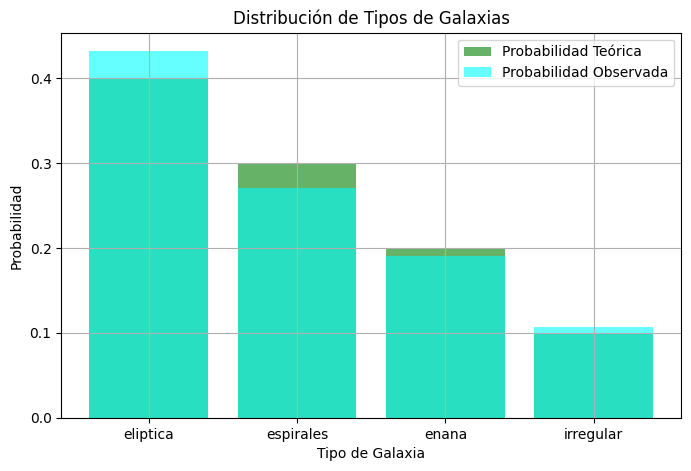

In [14]:
#primero, definimos las listas de galaxias y sus probabilidades

tipos_de_galaxias = ["eliptica", "espirales", "enana","irregular"]
probabilidades= [0.4,0.3,0.2,0.1]


# Definimos la funcion para generar las galaxias segun la distribucion de probabilidades dada
def generar_galaxias(n, a, c, M, x1):
    numeros = generador_congruencia_lineal(a, c, M, x1, n)
    probabilidades_acumuladas = np.cumsum(probabilidades)
    galaxias = [] # Lista para almacenar las galaxias generadas
    for r in numeros:  
        for i, pcum in enumerate(probabilidades_acumuladas): 
            if r < pcum: 
                galaxias.append(tipos_de_galaxias[i])
                break # Salir del bucle una vez que se encuentra la galaxia correspondiente
    return galaxias # Devolver la lista de galaxias generadas

# Generamos 1000 galaxias
n = 1000
galaxias = generar_galaxias(n, a, c, M, x1)

#contemos cuantas galaxias de cada tipo tenemos

conteo = Counter(galaxias) #Counter es una clase del modulo collections que nos permite contar la frecuencia de cada elemento en una lista, y devuelve un diccionario donde las claves son los elementos y los valores son las frecuencias
tipos_observados = list(conteo.keys()) #conteo.keys() devuelve las claves del diccionario conteo, que son los tipos de galaxias observados
frecuencias_observadas = list(conteo.values()) #conteo.values() devuelve los valores del diccionario conteo, que son las frecuencias observadas de cada tipo de galax
probabilidad_observada = [f/n for f in frecuencias_observadas] #calculamos las probabilidades observadas dividiendo las frecuencias observadas por n

# Mostramos un resumen de los resultados obtenidos
for tipo, count, prob in zip(tipos_observados, frecuencias_observadas, probabilidad_observada):
    print(f"Tipo de galaxia: {tipo}, Frecuencia: {count}, Probabilidad observada: {prob:.2f}")

# Graficamos la distribución de tipos de galaxias
plt.figure(figsize=(8, 5))
plt.bar(tipos_de_galaxias, probabilidades, color='green', alpha=0.6, label='Probabilidad Teórica')
plt.bar(tipos_observados, probabilidad_observada, color='cyan', alpha=0.6, label='Probabilidad Observada')
plt.xlabel('Tipo de Galaxia')
plt.ylabel('Probabilidad')
plt.title('Distribución de Tipos de Galaxias')
plt.legend()
plt.grid(True)
plt.show()